<a href="https://colab.research.google.com/github/GabrielaRguezCampos/GabrielaRguezCampos/blob/main/OOS_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📊 Model Accuracy:
MSE = 9.74
RMSE = 3.12
R² Score = 0.90

📋 Sample Predictions:
   Day   Quantity  Predicted_Quantity
0  181  84.677002           83.353226
1  182  79.028527           82.160073
2  183  77.187323           80.966920
3  184  80.647417           79.773767
4  185  77.329612           78.580614


<ipython-input-10-fd36e6397fe8>:63: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


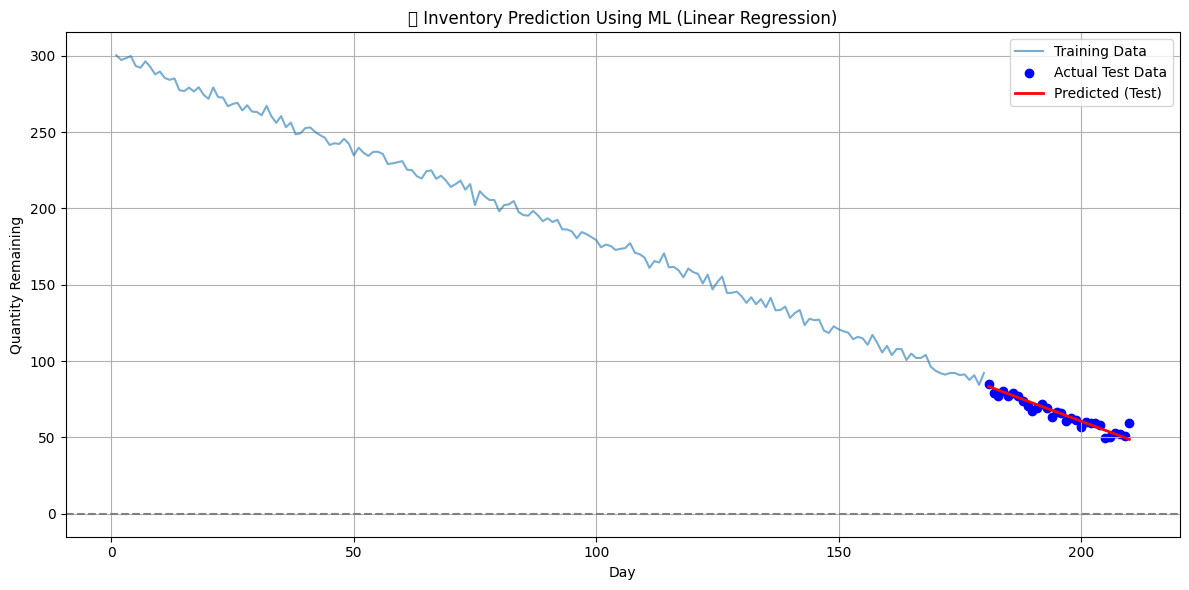

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Simulate 6 months (180 days) of training data
np.random.seed(42)
train_days = np.arange(1, 181)
true_daily_usage = 1.2
initial_quantity = 300
train_quantities = initial_quantity - true_daily_usage * train_days + np.random.normal(0, 3, len(train_days))

train_df = pd.DataFrame({
    'Day': train_days,
    'Quantity': train_quantities
})

# Step 2: Train the ML model
X_train = train_df[['Day']]
y_train = train_df['Quantity']
model = LinearRegression()
model.fit(X_train, y_train)

# Step 3: Simulate 30 days of test data
test_days = np.arange(181, 211)
test_quantities = initial_quantity - true_daily_usage * test_days + np.random.normal(0, 3, len(test_days))

test_df = pd.DataFrame({
    'Day': test_days,
    'Quantity': test_quantities
})

# Step 4: Predict and evaluate
X_test = test_df[['Day']]
y_test = test_df['Quantity']
y_pred = model.predict(X_test)

# Accuracy Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"📊 Model Accuracy:\nMSE = {mse:.2f}\nRMSE = {rmse:.2f}\nR² Score = {r2:.2f}")

# Step 5: Show prediction results
prediction_results = test_df.copy()
prediction_results['Predicted_Quantity'] = y_pred
print("\n📋 Sample Predictions:")
print(prediction_results.head())

# Step 6: Visualize
plt.figure(figsize=(12, 6))
plt.plot(train_df['Day'], train_df['Quantity'], label='Training Data', alpha=0.6)
plt.scatter(test_df['Day'], test_df['Quantity'], label='Actual Test Data', color='blue')
plt.plot(test_df['Day'], y_pred, label='Predicted (Test)', color='red', linewidth=2)
plt.axhline(0, linestyle='--', color='gray')
plt.title("📦 Inventory Prediction Using ML (Linear Regression)")
plt.xlabel("Day")
plt.ylabel("Quantity Remaining")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Example dataset with 3 variables (e.g., item usage for 3 different products)
data = {
    'Item_A': [10, 12, 13, 15, 16],
    'Item_B': [9, 11, 12, 14, 15],
    'Item_C': [2, 4, 3, 5, 4]
}

df = pd.DataFrame(data)

# Covariance matrix
cov_matrix = df.cov()
print("Covariance Matrix:")
print(cov_matrix)


Covariance Matrix:
        Item_A  Item_B  Item_C
Item_A     5.7     5.7     2.1
Item_B     5.7     5.7     2.1
Item_C     2.1     2.1     1.3


In [ ]:
import numpy as np
from scipy.signal import convolve

# Example inventory signal (e.g., daily sales)
inventory = np.array([10, 12, 11, 13, 9, 8, 10])

# Simple moving average kernel
kernel = np.array([1/3, 1/3, 1/3])

# Apply convolution
convolved = convolve(inventory, kernel, mode='valid')

print("Original Inventory:", inventory)
print("Convolved (Smoothed):", convolved)


Original Inventory: [10 12 11 13  9  8 10]
Convolved (Smoothed): [11. 12. 11. 10.  9.]
